In [2]:
import torchvision.transforms as T
import numpy as np
import os
import torch
from common import *
from matplotlib import pyplot as plt
import plotly.graph_objects as go
import plotly.io as pio
import PIL
import PIL.Image
import cv2
from kemsekov_torch.positional_emb import PositionalEncodingPermute
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.ndimage import affine_transform
import random
import skimage.measure
from scipy.ndimage import rotate
from scipy.spatial.transform import Rotation



Считываем информацию из файла 

In [3]:

class GeneratedDataset(torch.utils.data.Dataset):
    def __init__(self, images_dir, labels_dir, info_dir, images_transform=None, projections_order=['a', 'b']):
        super().__init__()
        
        self.projections_order = projections_order
        
        # Считываем разметку
        labels = os.listdir(labels_dir)
        index_to_label = {i.split('.')[0]: os.path.join(labels_dir, i) for i in labels}
        
        # Считываем изображения
        images = os.listdir(images_dir)
        image_labels = [i.split("image")[1].split(".")[0] for i in images]
        
        data = {}
        for image, label in zip(images, image_labels):
            label_index = label[:-1]
            label_letter = label[-1]
            if label_index not in data:
                data[label_index] = {}
            data[label_index][label_letter] = os.path.join(images_dir, image)
        
        # Добавляем метки и проекции
        for i in index_to_label:
            row = data[i]
            row['label'] = index_to_label[i]
            projections = [row[p] for p in projections_order]
            row['projections'] = projections
        
        # Загружаем углы проекций из info файлов
        self.angles = {}
        info_files = os.listdir(info_dir)
        for info_file in info_files:
            if info_file.endswith(".info.0"):  # Фильтруем нужные файлы
                info_path = os.path.join(info_dir, info_file)
                with open(info_path, 'r') as f:
                    info_data = json.load(f)
                case_id = info_file.split('.')[0]  # ID кейса
                self.angles[case_id] = {
                    'theta': info_data.get("theta_array", []),
                    'phi': info_data.get("phi_array", [])
                }
        
        self.data = data
        self.keys = list(self.data.keys())
        self.images_transform = images_transform if images_transform else lambda x: T.ToTensor()(x)
    
    def __len__(self):
        return len(self.keys)
    
    def __getitem__(self, index):
        key = self.keys[index]
        row = self.data[key]
        label = np.load(row['label'])
        images = [PIL.Image.open(v) for v in row['projections']]
        images = torch.concat([self.images_transform(i) for i in images])
        
        # Получаем углы для данного случая
        angles = self.angles.get(key, {'theta': [0] * len(self.projections_order), 'phi': [0] * len(self.projections_order)})
        theta = torch.tensor(angles['theta'], dtype=torch.float32)
        phi = torch.tensor(angles['phi'], dtype=torch.float32)
        
        return images, torch.tensor(label), theta, phi

In [4]:
labels_dir = "/home/alexus/Desktop/For_Generator/data0_1000/content/vessel_tree_generator/data/test/labels/test/"
images_dir = "/home/alexus/Desktop/For_Generator/data0_1000/content/vessel_tree_generator/data/test/images/test/"
info_dir = "/home/alexus/Desktop/For_Generator/data0_1000/content/vessel_tree_generator/data/test/info/"

def mean_channel(x):
    return x.mean(axis=0)[None,:]

def distance_transform(image_mask):
    image_mask=np.asarray(image_mask)[0]
    # Ensure the mask is binary
    binary_mask = (image_mask > np.mean(image_mask)).astype(np.uint8)
    # Apply the distance transform
    distance = cv2.distanceTransform(binary_mask, cv2.DIST_L2, 5)
    return torch.tensor(image_mask+distance[None,:])

images_transform=T.Compose([
    T.ToTensor(),
    T.Lambda(mean_channel),
    # T.Lambda(add_pos_encoding),
    # T.Lambda(lambda x: crop_to_content(x,0.5)),
    # T.CenterCrop((400,400)),
    
    T.Resize((128,128)),
    T.Lambda(distance_transform),
])
d2 = GeneratedDataset(images_dir,labels_dir,info_dir,images_transform=images_transform)

(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

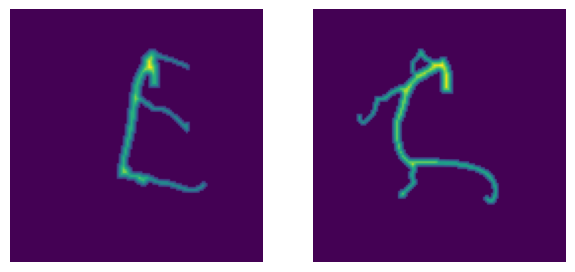

In [5]:
sample_index = 0 #random.randint(0,len(d)-1)
sample = d2[sample_index]
plt.figure(figsize=(15,15))
plt.subplot(1,4,1)
plt.imshow(sample[0][0])
plt.axis('off')
plt.subplot(1,4,2)
plt.imshow(sample[0][1])
plt.axis('off')


Создание 3д модели

In [6]:
output_3d_model = sample[1].numpy()

In [7]:
import plotly.graph_objects as go

def create_cylinder(p0, p1, r0, r1, resolution=40):
    p0 = np.array(p0)
    p1 = np.array(p1)
    # Vector from p0 to p1
    v = p1 - p0
    v = v / np.linalg.norm(v)
    
    # Create two vectors orthogonal to v
    if (v == np.array([0, 0, 1])).all():
        ortho1 = np.array([1, 0, 0])
    else:
        ortho1 = np.cross(v, [0, 0, 1])
        ortho1 /= np.linalg.norm(ortho1)
    ortho2 = np.cross(v, ortho1)
    
    # Angles for the circle
    theta = np.linspace(0, 2 * np.pi, resolution, endpoint=False)
    
    # Create circle at p0
    circle0 = [p0 + r0 * (np.cos(t) * ortho1 + np.sin(t) * ortho2) for t in theta]
    # Create circle at p1
    circle1 = [p1 + r1 * (np.cos(t) * ortho1 + np.sin(t) * ortho2) for t in theta]
 
    # Combine vertices
    vertices = np.vstack((circle0, circle1))
    
    # Create faces
    faces = []
    for i in range(resolution):
        next_i = (i + 1) % resolution
        # Triangle 1
        faces.append((i, next_i, resolution + i))
        # Triangle 2
        faces.append((next_i, resolution + next_i, resolution + i))
    
    return vertices, faces

def create_tube(centerline, radius, resolution=40):
    all_vertices = []
    all_faces = []
    vertex_offset = 0

    for i in range(len(centerline) - 1):
        p0 = centerline[i]
        p1 = centerline[i + 1]
        r0 = radius[i]
        r1 = radius[i + 1]
        
        vertices, faces = create_cylinder(p0, p1, r0, r1, resolution)
        all_vertices.append(vertices)
        # Adjust face indices
        adjusted_faces = [(a + vertex_offset, b + vertex_offset, c + vertex_offset) for a, b, c in faces]
        all_faces.extend(adjusted_faces)
        vertex_offset += vertices.shape[0]
    
    all_vertices = np.vstack(all_vertices)
    return all_vertices, all_faces

def crop_to_content(image: torch.Tensor, alpha_threshold: float = 0.1) -> torch.Tensor:
    # Extract the alpha channel
    alpha = image[-1, :, :]

    # Create a binary mask where alpha is above the threshold
    mask = alpha > alpha_threshold

    # Find the bounding box of the content
    non_zero_indices = mask.nonzero(as_tuple=False)
    if non_zero_indices.numel() == 0:
        # If there's no content, return the original image
        return image

    y_min, x_min = non_zero_indices.min(dim=0)[0]
    y_max, x_max = non_zero_indices.max(dim=0)[0]

    # Crop the image to the bounding box
    cropped_image = image[:, y_min:y_max + 1, x_min:x_max + 1]

    return cropped_image

def render_sample(sample):
    meshes = []
    tensor_list = []

    for branch in sample:
        tensor = branch  # [x, y, z, r]
        tensor_list.append(tensor)

        centerline = branch[:, :3]
        radius = branch[:, 3]
        vertices, faces = create_tube(centerline, radius, resolution=40)

        x, y, z = vertices[:, 0], vertices[:, 1], vertices[:, 2]
        I = [face[0] for face in faces]
        J = [face[1] for face in faces]
        K = [face[2] for face in faces]

        mesh = go.Mesh3d(x=x, y=y, z=z, i=I, j=J, k=K, color='lightblue', opacity=0.6, name='Tube')
        scatter = go.Scatter3d(
            x=[point[0] for point in centerline],
            y=[point[1] for point in centerline],
            z=[point[2] for point in centerline],
            mode='lines+markers', line=dict(color='red', width=4),
            marker=dict(size=1, color='red'), name='Centerline'
        )
        meshes.append(mesh)
        meshes.append(scatter)

    combined_tensor = np.vstack(tensor_list)
    return combined_tensor, meshes


def normalize_tensor(sample):
    centerline_copy = sample.copy()
    slice = centerline_copy[...,:3]
    scale = slice.max()-slice.min()

    centerline_copy[...,:3]-=slice.min()
    centerline_copy[...,:3]/=slice.max()
    centerline_copy[...,-1]/=scale
    
    return centerline_copy 

output_3d_model = normalize_tensor(output_3d_model)
tensor, meshes = render_sample(output_3d_model)

# Визуализация (опционально)
layout = go.Layout(
    title='3D Tube Visualization',
    scene=dict(xaxis=dict(title='X'), yaxis=dict(title='Y'), zaxis=dict(title='Z'), aspectmode='data'),
    legend=dict(x=0.7, y=0.9), width=700, height=700
)
fig = go.Figure(data=meshes, layout=layout)
fig.show()



In [8]:
from ipywidgets import interact
from scipy.ndimage import zoom


# Устанавливаем volume_shape
volume_shape = (128, 128, 128)

# Создание T из label с оптимизацией
T = torch.zeros(volume_shape, dtype=torch.float32)
output_3d_model = normalize_tensor(output_3d_model)

for group in range(output_3d_model.shape[0]):
    # Масштабируем координаты на диапазон [0, 127], сдвигаем к центру
    x = (output_3d_model[group, :, 0] * 100 + 10).astype(int).clip(0, 127)
    y = (output_3d_model[group, :, 1] * 100 + 10).astype(int).clip(0, 127)
    z = (output_3d_model[group, :, 2] * 100 + 10).astype(int).clip(0, 127)
    R = torch.tensor(output_3d_model[group, :, 3], dtype=torch.float32) * 10  # Увеличиваем интенсивность
    print(f"Group {group} R min, max:", R.min().item(), R.max().item())
    
    for i in range(len(x)):
        radius = int((R[i] * 12).clamp(1, 10))  # Уменьшаем радиус для ускорения
        x_grid, y_grid, z_grid = torch.meshgrid(
            torch.arange(-radius, radius + 1),
            torch.arange(-radius, radius + 1),
            torch.arange(-radius, radius + 1)
        )
        mask = (x_grid ** 2 + y_grid ** 2 + z_grid ** 2 <= radius ** 2)
        x_shifted = x[i] + x_grid[mask]
        y_shifted = y[i] + y_grid[mask]
        z_shifted = z[i] + z_grid[mask]
        valid = (x_shifted >= 0) & (x_shifted < 128) & (y_shifted >= 0) & (y_shifted < 128) & (z_shifted >= 0) & (z_shifted < 128)
        x_valid, y_valid, z_valid = x_shifted[valid], y_shifted[valid], z_shifted[valid]
        for x_v, y_v, z_v in zip(x_valid, y_valid, z_valid):
            if T[x_v, y_v, z_v] == 0:
                T[x_v, y_v, z_v] = R[i]
            else:
                T[x_v, y_v, z_v] = (T[x_v, y_v, z_v] + R[i]) / 2

Group 0 R min, max: 0.09845121949911118 0.30074581503868103
Group 1 R min, max: 0.07761619985103607 0.12290530651807785


/home/alexus/Desktop/For_Generator/kemsekov_torch/__pycache__/.venv/lib/python3.12/site-packages/torch/functional.py:534: UserWarning:

torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ../aten/src/ATen/native/TensorShape.cpp:3595.)



Group 2 R min, max: 0.07148083299398422 0.13825160264968872
Group 3 R min, max: 0.10229004919528961 0.15493640303611755


In [9]:

pio.templates.default = "plotly_dark"
plt.style.use('dark_background')
nonzero_indices = T.nonzero(as_tuple=False)  # Возвращает тензор формы (кол-во ненулевых, 3)
values = T[nonzero_indices[:, 0], nonzero_indices[:, 1], nonzero_indices[:, 2]]  # Значения в этих точках

# Преобразуем в списки для Plotly
x_coords = nonzero_indices[:, 0].tolist()
y_coords = nonzero_indices[:, 1].tolist()
z_coords = nonzero_indices[:, 2].tolist()
radii = values.tolist()  # Яркость или размер точек

# Создаём 3D Scatter plot
fig = go.Figure(data=[go.Scatter3d(
    x=x_coords,
    y=y_coords,
    z=z_coords,
    mode='markers',
    marker=dict(
        size=[r * 100 for r in radii],  # Увеличиваем радиус для видимости
        color=radii,                    # Цвет зависит от значения радиуса
        colorscale='Viridis',           # Цветовая шкала
        opacity=0.8,
        colorbar=dict(title="Radius")   # Добавляем шкалу
    )
)])


# Настраиваем внешний вид
fig.update_layout(
    title="3D Visualization of Tensor T",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Z",
        aspectmode='cube'  # Кубическая форма для равных осей   
    ), width=700, height=700
)

# Показываем график
fig.show()

Обратное преобразование

In [10]:
images, label, theta, phi = d2[sample_index]
proj1 = images[0].cpu().numpy()
proj2 = images[1].cpu().numpy()
phi1, phi2 =phi[0].item(), phi[1].item()
theta1, theta2 = theta[0].item(), theta[1].item()

if proj1.max() > 1.0:
    proj1 = proj1 / proj1.max()  # Normalize to [0, 1]
    proj2 = proj2 / proj2.max()

In [11]:
print(f'phi1 = {phi1}, phi2 = {phi2}, theta1 = {theta1}, theta2 = {theta2}', ) # - Углы ангиографа

phi1 = -100.0, phi2 = -99.30917358398438, theta1 = -130.0, theta2 = -16.34215545654297


In [12]:
# Функция для создания тени от проекции
def create_shadow(projection, phi, theta, volume_shape=(128, 128, 128), threshold=0.1):
    D_x, D_y, D_z = volume_shape 
    projection = zoom(projection, (D_x / projection.shape[0], D_y / projection.shape[1]), order=1)
    binary_proj = torch.tensor((projection > threshold) * projection, dtype=torch.float32)
    h, w = binary_proj.shape
    vol = torch.zeros(volume_shape, dtype=torch.float32)
    x0, y0 = (D_x - w) // 2, (D_y - h) // 2
    vol[y0:y0+h, x0:x0+w, 0] = binary_proj
    y_coords, x_coords = torch.where(vol[:, :, 0] > 0)
    intensities = vol[y0:y0+h, x0:x0+w, 0][y_coords - y0, x_coords - x0]
    phi_rad, theta_rad = torch.tensor(np.radians(phi)), torch.tensor(np.radians(theta))
    dx = torch.cos(phi_rad) * torch.cos(theta_rad)
    dy = torch.sin(phi_rad) * torch.cos(theta_rad)
    dz = torch.sin(theta_rad)
    norm = torch.sqrt(dx**2 + dy**2 + dz**2)
    dx, dy, dz = dx / norm, dy / norm, dz / norm
    z_indices = torch.arange(D_z, dtype=torch.long)
    shadow_x = x_coords[:, None] + dx * z_indices[None, :]
    shadow_y = y_coords[:, None] + dy * z_indices[None, :]
    shadow_z = z_indices[None, :].repeat(len(x_coords), 1)
    shadow_x = shadow_x.round().long().clamp(0, D_x - 1)
    shadow_y = shadow_y.round().long().clamp(0, D_y - 1)
    shadow_z = shadow_z.clamp(0, D_z - 1)
    for i in range(len(x_coords)):
        for j in range(D_z):
            if shadow_z[i, j] < D_z:
                vol[shadow_y[i, j], shadow_x[i, j], shadow_z[i, j]] = intensities[i]
    return vol


def rotate_tensor(tensor, phi, theta, volume_shape):
    D_x, D_y, D_z = volume_shape
    rotated_tensor = torch.zeros_like(tensor)

    phi_rad = np.radians(phi)
    theta_rad = np.radians(theta)

    Rz = torch.tensor([
        [np.cos(phi_rad), -np.sin(phi_rad), 0],
        [np.sin(phi_rad), np.cos(phi_rad), 0],
        [0, 0, 1]
    ], dtype=torch.float32)
    Ry = torch.tensor([
        [np.cos(theta_rad), 0, np.sin(theta_rad)],
        [0, 1, 0],
        [-np.sin(theta_rad), 0, np.cos(theta_rad)]
    ], dtype=torch.float32)
    R = torch.matmul(Ry, Rz)

    coords = torch.where(tensor > 0.01)
    points = torch.stack(coords, dim=-1).float() - torch.tensor([D_x/2, D_y/2, D_z/2], dtype=torch.float32)
    intensities = tensor[coords]

    rotated_points = torch.matmul(points, R.T)
    rotated_points = rotated_points + torch.tensor([D_x/2, D_y/2, D_z/2], dtype=torch.float32)
    rotated_points = rotated_points.round().long()

    valid = (rotated_points[:, 0] >= 0) & (rotated_points[:, 0] < D_x) & \
            (rotated_points[:, 1] >= 0) & (rotated_points[:, 1] < D_y) & \
            (rotated_points[:, 2] >= 0) & (rotated_points[:, 2] < D_z)

    rotated_points = rotated_points[valid]
    intensities = intensities[valid]

    for i in range(len(rotated_points)):
        x, y, z = rotated_points[i]
        if rotated_tensor[x, y, z] == 0:
            rotated_tensor[x, y, z] = intensities[i]

    return rotated_tensor

# Функция для размещения сосуда с интерактивной высотой
def place_T_with_offset(T, z_offset, volume_shape=(128, 128, 128)):
    D_x, D_y, D_z = volume_shape
    T_shifted = torch.zeros(volume_shape, dtype=torch.float32)
    z_min = max(0, z_offset)
    z_max = min(D_z, T.shape[2] + z_offset)
    if z_max > z_min:
        T_shifted[:, :, z_min:z_max] = T[:, :, :z_max - z_min]
    return T_shifted

# Создаём тени
shadow1 = create_shadow(proj1, phi1, theta1, volume_shape, threshold=0.1)
shadow2 = create_shadow(proj2, phi2, theta2, volume_shape, threshold=0.1)

# Интерактивная визуализация с поворотом
def update_visualization(z_offset=0, phi=phi2, theta=theta2):
    # Смещаем и поворачиваем T
    T_shifted = place_T_with_offset(T, z_offset, volume_shape)
    T_rotated = rotate_tensor(T_shifted, phi, theta, volume_shape)

    x = np.arange(volume_shape[0])
    y = np.arange(volume_shape[1])
    z = np.arange(volume_shape[2])

    fig = go.Figure()
    
    # Тень 1 (только точки с интенсивностью > 0.2)
    shadow1_coords = torch.where(shadow1 > 0.2)
    fig.add_trace(go.Scatter3d(
        x=shadow1_coords[0].numpy(), y=shadow1_coords[1].numpy(), z=shadow1_coords[2].numpy(),
        mode='markers', marker=dict(size=2, color='blue', opacity=0.9), name='Shadow 1'
    ))
    
    # Тень 2 (только точки с интенсивностью > 0.2)
    shadow2_coords = torch.where(shadow2 > 0.2)
    fig.add_trace(go.Scatter3d(
        x=shadow2_coords[0].numpy(), y=shadow2_coords[1].numpy(), z=shadow2_coords[2].numpy(),
        mode='markers', marker=dict(size=2, color='green', opacity=0.9), name='Shadow 2'
    ))
    
    # Сосуд T после поворота (только точки с интенсивностью > 0.01)
    T_coords = torch.where(T_rotated > 0.01)
    fig.add_trace(go.Scatter3d(
        x=T_coords[0].numpy(), y=T_coords[1].numpy(), z=T_coords[2].numpy(),
        mode='markers', marker=dict(size=3, color='red', opacity=0.5), name='Rotated T'
    ))
    
    fig.update_layout(
        title="3D Points: Shadows and Rotated T with Interactive Z-Offset and Rotation",
        scene=dict(
            xaxis=dict(range=[0, 128], title='X'),
            yaxis=dict(range=[0, 128], title='Y'),
            zaxis=dict(range=[0, 128], title='Z')
        ),
        width=1200, height=800
    )
    fig.show()

# Запуск интерактивного управления
interact(update_visualization, z_offset=(-63, 63, 1), phi=(-140, 120, 5), theta=(-140, 180, 5))

interactive(children=(IntSlider(value=0, description='z_offset', max=63, min=-63), IntSlider(value=-99, descri…

<function __main__.update_visualization(z_offset=0, phi=-99.30917358398438, theta=-16.34215545654297)>